CÓDIGO PÉNDULO SIMPLE

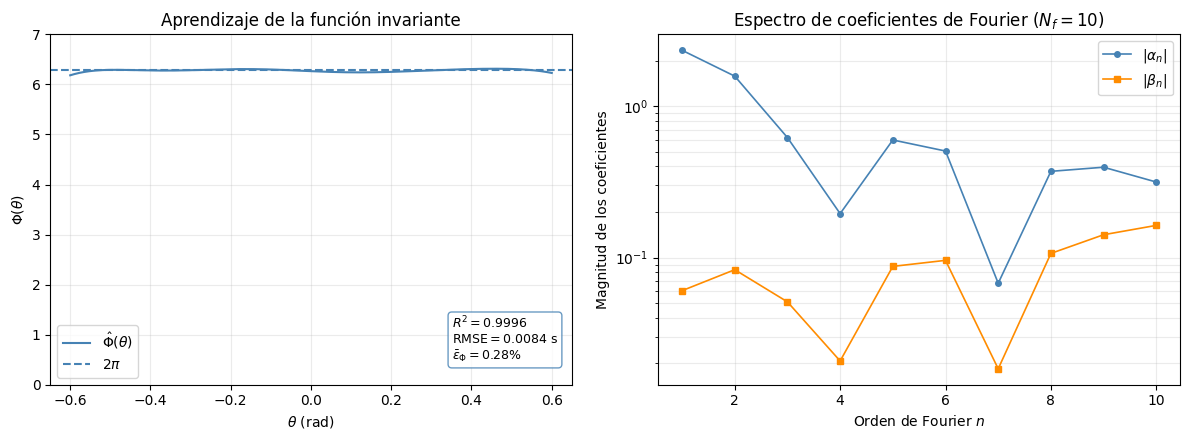

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split # Añadimos el import

rng = np.random.default_rng(42)  # semilla fija para que los resultados sean reproducibles


# parametros físicos y de simulación
g = 9.8
N_long, N_rep = 80, 5       # 80 longitudes distintas, 5 repeticiones cada una
sigma = 0.02                 # nivel de ruido relativo sobre el periodo
Nf = 10                       # orden del diccionario de Fourier
th_min, th_max = -0.55, 0.55   # rango de ángulos (pequeñas oscilaciones)
L_min, L_max = 0.5, 2.0          # rango de longitudes del péndulo (m)


# generación de los datos sintéticos
L_data   = rng.uniform(L_min, L_max, N_long * N_rep)
th_data  = rng.uniform(th_min, th_max, N_long * N_rep)
T_teorico = 2 * np.pi * np.sqrt(L_data / g)
T_medido  = T_teorico * (1 + sigma * rng.standard_normal(len(T_teorico)))


#Preparación de los datos
#   T = P(L,g) * Phi(theta),  con P = sqrt(L/g)
Pre_dim = np.sqrt(L_data / g)
Phi_medido = T_medido / Pre_dim

# Dicionario de funciones de Fourier para aproximar la función 
def build_features(theta, orden):
    cols = [np.ones(len(theta))]
    for k in range(1, orden + 1):
        cols.append(np.cos(k * theta))
        cols.append(np.sin(k * theta))
    return np.column_stack(cols)

X_feat = build_features(th_data, Nf)


#Separamos los datos en train y test
(X_train, X_test, 
 Phi_train, Phi_test, 
 Pre_dim_train, Pre_dim_test, 
 T_teorico_train, T_teorico_test) = train_test_split(X_feat, Phi_medido, Pre_dim, T_teorico, 
                                                     test_size=0.2, random_state=42)


#Entrenamiento del modelo  
alphas_grid = np.logspace(-5, 1, 80)
modelo  = RidgeCV(alphas=alphas_grid, fit_intercept=False)
modelo.fit(X_train, Phi_train)

coefs_ridge = modelo.coef_
a_n = coefs_ridge[1::2]   # coeficientes de los cosenos
b_n = coefs_ridge[2::2]   # coeficientes de los senos



#Evaluacion del modelo con el conjunto de test y comparación el valor teórico de Phi 
Phi_pred = modelo.predict(X_test)
T_pred   = Phi_pred * Pre_dim_test
r2_test   = r2_score(T_teorico_test, T_pred)
rmse_test = np.sqrt(mean_squared_error(T_teorico_test, T_pred))
err_phi   = np.mean(np.abs(Phi_pred - 2 * np.pi)) / (2 * np.pi) * 100


# Se extiende un poco el rango de theta respecto al de entrenamiento
th_plot   = np.linspace(-0.6, 0.6, 1000)
Phi_raw   = modelo.predict(build_features(th_plot, Nf))
Phi_curva = np.clip(Phi_raw, 0, None)  # se recorta para que no salgan valores negativos sin sentido físico


# Generación de las gráficas
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Gráfica de la función invariante Phi(theta)
ax1 = axes[0]
ax1.plot(th_plot, Phi_curva, color='steelblue', lw=1.5,
         label=r'$\hat{\Phi}(\theta)$')
ax1.axhline(2 * np.pi, color='steelblue', lw=1.5, ls='--',
            label=r'$2\pi$')
ax1.set_xlabel(r'$\theta$ (rad)')
ax1.set_ylabel(r'$\Phi(\theta)$')
ax1.set_title('Aprendizaje de la función invariante')
ax1.set_xlim(-0.65, 0.65)
ax1.set_ylim(0, 7)
ax1.legend()
ax1.grid(True, alpha=0.25)

# Cuadro de métricas R^2, RMSE y error relativo
texto_caja = (f'$R^2 = {r2_test:.4f}$\n'
           f'$\\mathrm{{RMSE}} = {rmse_test:.4f}$ s\n'
           f'$\\bar{{\\epsilon}}_\\Phi = {err_phi:.2f}\\%$')
props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='steelblue')
ax1.text(0.77, 0.20, texto_caja, transform=ax1.transAxes,
         fontsize=9, verticalalignment='top', bbox=props)

# Gráfica de los coeficientes de Fourier
ax2 = axes[1]
ns  = np.arange(1, Nf + 1)
ax2.semilogy(ns, np.abs(a_n), 'o-', color='steelblue',
             ms=4, lw=1.2, label=r'$|\alpha_n|$')
ax2.semilogy(ns, np.abs(b_n),  's-', color='darkorange',
             ms=4, lw=1.2, label=r'$|\beta_n|$')
ax2.set_xlabel('Orden de Fourier $n$')
ax2.set_ylabel('Magnitud de los coeficientes')
ax2.set_title(f'Espectro de coeficientes de Fourier ($N_f = {Nf}$)')
ax2.legend()
ax2.grid(True, which='both', alpha=0.25)

plt.tight_layout()
plt.savefig('pendulo_graficas.png', dpi=150, bbox_inches='tight')
plt.show()